Device: cuda

Dataset: MNIST

  ── Subset 0.2% (120 samples, 12/class) ──
    seed=42 | Top-1=25.45% | Macro-F1=0.1735 | 4s
    seed=123 | Top-1=35.30% | Macro-F1=0.2833 | 4s
    seed=456 | Top-1=24.46% | Macro-F1=0.1757 | 4s
    seed=789 | Top-1=19.86% | Macro-F1=0.1312 | 4s
    seed=1011 | Top-1=23.16% | Macro-F1=0.1266 | 4s

  ── Subset 0.5% (300 samples, 30/class) ──
    seed=42 | Top-1=87.80% | Macro-F1=0.8730 | 4s
    seed=123 | Top-1=90.50% | Macro-F1=0.9030 | 4s
    seed=456 | Top-1=91.05% | Macro-F1=0.9110 | 4s
    seed=789 | Top-1=88.86% | Macro-F1=0.8868 | 4s
    seed=1011 | Top-1=92.74% | Macro-F1=0.9273 | 4s

  ── Subset 1% (600 samples, 60/class) ──
    seed=42 | Top-1=92.64% | Macro-F1=0.9265 | 5s
    seed=123 | Top-1=94.40% | Macro-F1=0.9439 | 5s
    seed=456 | Top-1=94.95% | Macro-F1=0.9490 | 5s
    seed=789 | Top-1=94.98% | Macro-F1=0.9491 | 5s
    seed=1011 | Top-1=93.35% | Macro-F1=0.9322 | 5s

  ── Subset 2% (1200 samples, 120/class) ──
    seed=42 | Top-1=95.22% |

100%|██████████| 170M/170M [49:33<00:00, 57.3kB/s]   



  ── Subset 0.2% (100 samples, 10/class) ──
    seed=42 | Top-1=22.45% | Macro-F1=0.1942 | 5s
    seed=123 | Top-1=23.29% | Macro-F1=0.1922 | 5s
    seed=456 | Top-1=25.10% | Macro-F1=0.2322 | 5s
    seed=789 | Top-1=24.34% | Macro-F1=0.2143 | 5s
    seed=1011 | Top-1=21.46% | Macro-F1=0.1639 | 5s

  ── Subset 0.5% (250 samples, 25/class) ──
    seed=42 | Top-1=31.74% | Macro-F1=0.3196 | 6s
    seed=123 | Top-1=34.33% | Macro-F1=0.3366 | 6s
    seed=456 | Top-1=32.30% | Macro-F1=0.3271 | 6s
    seed=789 | Top-1=33.85% | Macro-F1=0.3273 | 6s
    seed=1011 | Top-1=32.93% | Macro-F1=0.3178 | 6s

  ── Subset 1% (500 samples, 50/class) ──
    seed=42 | Top-1=43.58% | Macro-F1=0.4314 | 7s
    seed=123 | Top-1=41.36% | Macro-F1=0.4117 | 7s
    seed=456 | Top-1=36.39% | Macro-F1=0.3543 | 7s
    seed=789 | Top-1=38.29% | Macro-F1=0.3721 | 7s
    seed=1011 | Top-1=42.90% | Macro-F1=0.4203 | 8s

  ── Subset 2% (1000 samples, 100/class) ──
    seed=42 | Top-1=50.86% | Macro-F1=0.5085 | 11s
    se

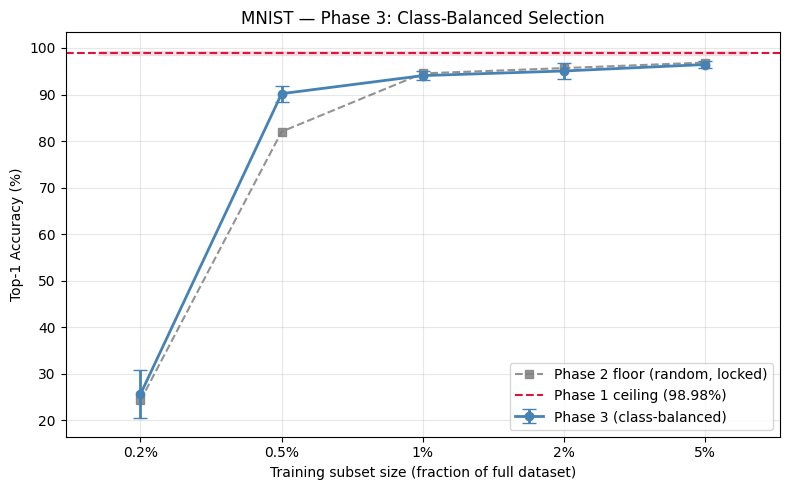

Saved: /kaggle/working/plots/phase3_MNIST_accuracy_curve.png


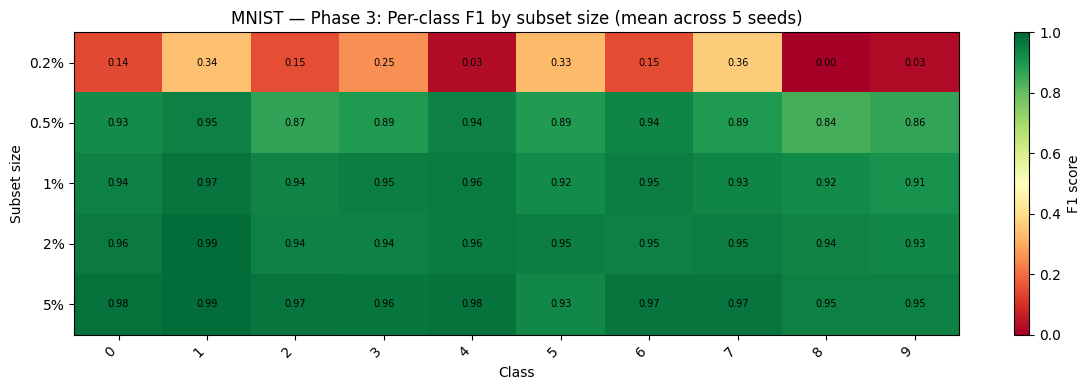

Saved: /kaggle/working/plots/phase3_MNIST_perclass_f1.png


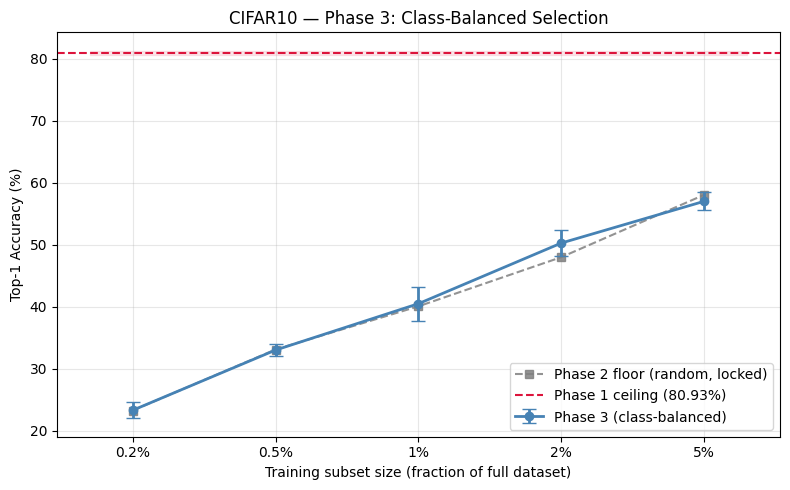

Saved: /kaggle/working/plots/phase3_CIFAR10_accuracy_curve.png


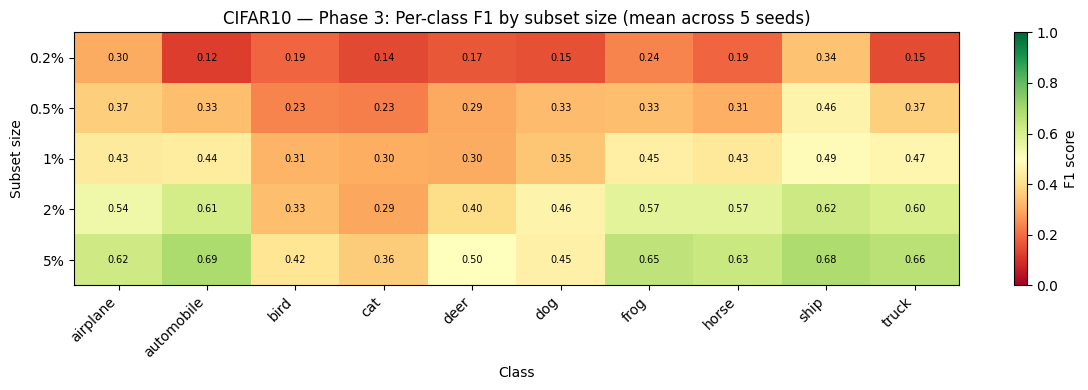

Saved: /kaggle/working/plots/phase3_CIFAR10_perclass_f1.png

Phase 3 complete. All checkpoints, results JSON, and plots saved.
Checkpoints : /kaggle/working/checkpoints
Results JSON: /kaggle/working/results/phase3_results.json
Plots       : /kaggle/working/plots


In [2]:
# ============================================================
# SECTION 1 — IMPORTS & CONFIG
# ============================================================

import os, json, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

# ── Fixed constants — never change across phases ──────────────
SEEDS         = [42, 123, 456, 789, 1011]
SUBSET_FRACS  = [0.002, 0.005, 0.01, 0.02, 0.05]
SUBSET_LABELS = ['0.2%', '0.5%', '1%', '2%', '5%']
BATCH_SIZE    = 128
NUM_WORKERS   = 2
EPOCHS        = {'MNIST': 20, 'CIFAR10': 30}

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

CHECKPOINT_DIR = '/kaggle/working/checkpoints'
RESULTS_DIR    = '/kaggle/working/results'
PLOT_DIR       = '/kaggle/working/plots'
for d in [CHECKPOINT_DIR, RESULTS_DIR, PLOT_DIR]:
    os.makedirs(d, exist_ok=True)

# ============================================================
# SECTION 2 — SEEDING UTILITIES   (identical to Phase 1/2)
#
# set_seed: fixes main process (Python, NumPy, PyTorch, CUDA).
# seed_worker: fixes each DataLoader worker subprocess.
#   Without it, workers use OS-random seeds when num_workers > 0.
#   torch.initial_seed() returns the seed PyTorch assigned that
#   worker; we propagate it to NumPy and Python random.
# cudnn.deterministic: forces deterministic CUDA ops.
# cudnn.benchmark = False: stops CUDA picking a faster but
#   non-deterministic algorithm between runs.
# ============================================================

def set_seed(seed: int):
    """Fix all random sources in the main process."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def seed_worker(worker_id):
    """Called once per DataLoader worker at startup."""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


# ============================================================
# SECTION 3 — TRANSFORMS & DATASET BUILDERS   (identical to P1/2)
#
# MNIST: normalise only, no augmentation.
# CIFAR train: RandomHorizontalFlip + RandomCrop(32,padding=4)
#   + normalise. Test: normalise only.
# Augmentation on test would inflate scores — never do it.
# The CIFAR augmentation is a declared confound: it is kept ON
# and IDENTICAL across every phase, so it cancels out in any
# phase-to-phase comparison.
# ============================================================

def get_transforms(dataset_name: str, train: bool):
    """Return correct transform pipeline for each dataset and split."""
    if dataset_name == 'MNIST':
        return transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ])
    else:  # CIFAR10
        if train:
            return transforms.Compose([
                transforms.RandomHorizontalFlip(),      # flip with p=0.5
                transforms.RandomCrop(32, padding=4),  # pad 4px each side, crop to 32
                transforms.ToTensor(),
                transforms.Normalize(
                    (0.4914, 0.4822, 0.4465),
                    (0.2023, 0.1994, 0.2010)
                )
            ])
        else:
            return transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize(
                    (0.4914, 0.4822, 0.4465),
                    (0.2023, 0.1994, 0.2010)
                )
            ])

def get_datasets(dataset_name: str):
    """Download and return full train + test datasets."""
    root = '/kaggle/working/data'
    if dataset_name == 'MNIST':
        train_ds = torchvision.datasets.MNIST(
            root, train=True,  download=True,
            transform=get_transforms('MNIST', True))
        test_ds  = torchvision.datasets.MNIST(
            root, train=False, download=True,
            transform=get_transforms('MNIST', False))
    else:
        train_ds = torchvision.datasets.CIFAR10(
            root, train=True,  download=True,
            transform=get_transforms('CIFAR10', True))
        test_ds  = torchvision.datasets.CIFAR10(
            root, train=False, download=True,
            transform=get_transforms('CIFAR10', False))
    return train_ds, test_ds


# ============================================================
# SECTION 4 — SAMPLING FUNCTION  (Phase 3 core — THE ONLY CHANGE)
#
# Signature is fixed across all phases:  (dataset, fraction, seed) -> list[int]
# WHAT CHANGES vs Phase 2, and ONLY this:
#   Phase 2 drew `n_sample` indices uniformly over the whole pool,
#   so class counts were a random multinomial. At 0.2% CIFAR (100
#   imgs) one class might get 3 and another 17 — a starved class
#   tanks its per-class F1, and because Macro-F1 averages over
#   classes, one near-dead class drags the whole score down. That
#   is the mechanism behind Phase 2's large variance at small sizes.
#
#   Phase 3 forces EXACTLY n_sample/num_classes images per class,
#   chosen uniformly at random WITHIN each class. The total count
#   is unchanged; only the class proportions move from random to
#   forced-uniform. So (Phase 3 - Phase 2) measures the causal
#   effect of class balance ALONE.
#
# WHY within-class selection stays random — on purpose:
#   This is the CONTROL baseline (per second-marker feedback). It
#   isolates a single variable (class balance) with zero importance
#   scoring. Phases 4-5 then add intelligent within-class selection
#   on top, so (Phase 4/5 - Phase 3) isolates that second effect.
#
# np.random.default_rng(seed) is an ISOLATED RNG — it does NOT
# touch the global NumPy state fixed in set_seed, so sampling never
# consumes random numbers meant for model weight initialisation.
# ============================================================

def sample_indices(dataset, fraction: float, seed: int) -> list:
    """
    PHASE 3: Class-balanced (stratified) sampling.
    Returns a list of integer indices into `dataset`, with an equal
    number drawn from each class (remainder spread one-per-class).
    """
    rng      = np.random.default_rng(seed)          # isolated RNG (same pattern as Phase 2)
    n_total  = len(dataset)
    n_sample = max(1, int(n_total * fraction))      # SAME total as Phase 2 (floor, min 1)

    # Labels WITHOUT loading any images: torchvision exposes integer
    # targets directly. np.asarray handles both MNIST (a tensor) and
    # CIFAR-10 (a python list). Iterating the dataset instead would
    # apply the transforms to every image and be far slower.
    labels      = np.asarray(dataset.targets)
    classes     = np.unique(labels)                 # [0..9] for both datasets
    num_classes = len(classes)

    # Per-class quota. If n_sample is not divisible by num_classes,
    # give the leftover out one-per-class to the first `remainder`
    # classes, so the indices sum EXACTLY to n_sample — we never
    # silently drop or add images. (All five configured sizes divide
    # evenly by 10, so in practice remainder == 0 here.)
    base      = n_sample // num_classes
    remainder = n_sample %  num_classes
    assert base >= 1, (
        f'Subset of {n_sample} is too small for {num_classes} classes '
        f'(<1 per class). All configured subset sizes satisfy base >= 1.'
    )

    selected = []
    for k, cls in enumerate(classes):
        cls_indices = np.where(labels == cls)[0]              # every index with label == cls
        quota       = base + (1 if k < remainder else 0)      # spread the remainder
        chosen      = rng.choice(cls_indices, size=quota, replace=False)  # random within class, no repeats
        selected.extend(chosen.tolist())

    # Shuffle once so the saved index list is not class-ordered.
    # (The DataLoader re-shuffles every epoch anyway, so this does
    #  NOT affect training — it is purely for tidy, inspectable output.)
    rng.shuffle(selected)

    # PROOF of balance — assert the realised per-class counts match
    # the intended quota. Makes correctness checkable, not assumed;
    # this is the line that lets the code *demonstrate* the subset
    # is balanced rather than us claiming it.
    counts   = np.bincount(labels[selected], minlength=num_classes)
    expected = np.full(num_classes, base)
    expected[:remainder] += 1
    assert np.array_equal(np.sort(counts), np.sort(expected)), (
        f'Class-balance check FAILED: realised counts = {counts.tolist()}'
    )

    return selected


# ============================================================
# SECTION 5 — MODEL (SimpleCNN — identical to Phase 1/2)
#
# 3 conv blocks: Conv->BN->ReLU->MaxPool, channels 32->64->128.
# AdaptiveAvgPool2d(2,2): fixes output at 2x2 regardless of
#   input size. 128*2*2 = 512 features after Flatten.
# Linear(512,256) -> ReLU -> Dropout(0.5) -> Linear(256,10).
# No softmax: CrossEntropyLoss applies log-softmax internally.
# (2,2) chosen over (1,1) to retain more spatial information.
# ============================================================

class SimpleCNN(nn.Module):
    def __init__(self, in_channels: int = 1, num_classes: int = 10):
        super().__init__()
        # Block 1: in_channels -> 32, spatial /2
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2)
        )
        # Block 2: 32 -> 64, spatial /2
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2)
        )
        # Block 3: 64 -> 128, spatial /2
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2)
        )
        # Fixed 2x2 spatial output -> 512 features when flattened
        self.pool = nn.AdaptiveAvgPool2d((2, 2))
        # Classifier head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 2 * 2, 256),  # 512 -> 256
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)    # raw logits, no softmax
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.pool(x)
        return self.classifier(x)


# ============================================================
# SECTION 6 — TRAIN & EVAL LOOPS   (identical to Phase 1/2)
#
# train_epoch: one full pass. Returns (mean_loss, accuracy) so the
#   scheduler can step on TRAINING loss (no validation split —
#   consistent with P1/P2, a declared caveat).
# evaluate: model.eval() disables Dropout and switches BatchNorm to
#   running stats. torch.no_grad() disables gradient tracking.
#   zero_division=0: F1=0 for classes with no predictions (can still
#   happen at 0.2% even when the TRAIN subset is balanced — expected).
# ============================================================

def train_epoch(model, loader, criterion, optimiser, device):
    """One training pass. Returns (mean_loss, accuracy)."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimiser.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimiser.step()

        total_loss += loss.item() * images.size(0)  # un-average to get sum
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, device):
    """Full evaluation on test set. Returns (top1_pct, macro_f1, per_class_f1)."""
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            preds  = model(images).argmax(1).cpu()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.tolist())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    top1         = (all_preds == all_labels).mean() * 100
    macro_f1     = f1_score(all_labels, all_preds, average='macro',  zero_division=0)
    per_class_f1 = f1_score(all_labels, all_preds, average=None,     zero_division=0)

    return top1, macro_f1, per_class_f1


# ============================================================
# SECTION 7 — EXPERIMENT HARNESS   (identical to Phase 2 except
# the sampling call comment + checkpoint/JSON names)
#
# Nested loop: dataset -> subset_size -> seed (2 x 5 x 5 = 50 runs).
# - set_seed FIRST, before any other operation each run
# - sample_indices uses an isolated RNG (doesn't disturb set_seed)
# - Subset is a lightweight index-based view — no data copied
# - Generator seeds DataLoader shuffle order deterministically
# - batch_size guard for subsets smaller than 128
# - Fresh model/optimiser/scheduler per seed — no state leaks
# - Scheduler steps on training loss (no val split, same as P1/P2)
# - Checkpoint naming: phase3_balanced_{ds}_seed{s}_{size}.pth
# ============================================================

DATASET_CONFIGS = {
    'MNIST':   {'in_channels': 1},
    'CIFAR10': {'in_channels': 3},
}

results = {}  # results[ds_name][label][str(seed)] = {top1, macro_f1, per_class_f1}

for ds_name, ds_cfg in DATASET_CONFIGS.items():
    print(f"\n{'='*60}\nDataset: {ds_name}\n{'='*60}")
    results[ds_name] = {}

    train_ds, test_ds = get_datasets(ds_name)

    # Test loader — fixed, never subsampled, identical across all phases
    test_loader = DataLoader(
        test_ds, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True
    )

    for frac, label in zip(SUBSET_FRACS, SUBSET_LABELS):
        n_samples = max(1, int(len(train_ds) * frac))
        print(f"\n  ── Subset {label} ({n_samples} samples, "
              f"{n_samples // 10}/class) ──")
        results[ds_name][label] = {}

        for seed in SEEDS:
            t0 = time.time()
            set_seed(seed)  # fix global state FIRST

            # ── Sample ──────────────────────────────────────────
            indices = sample_indices(train_ds, frac, seed)  # Phase 3: class-balanced
            subset  = Subset(train_ds, indices)              # index-based view, no copy

            g = torch.Generator()
            g.manual_seed(seed)  # seeds DataLoader shuffle order

            train_loader = DataLoader(
                subset,
                batch_size=min(BATCH_SIZE, len(subset)),  # guard for tiny subsets
                shuffle=True,
                num_workers=NUM_WORKERS,
                worker_init_fn=seed_worker,
                generator=g,
                pin_memory=True
            )

            # ── Model — fresh every run, no state leaks ──────────
            model     = SimpleCNN(in_channels=ds_cfg['in_channels']).to(DEVICE)
            criterion = nn.CrossEntropyLoss()
            optimiser = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                optimiser, mode='min', factor=0.5, patience=3
            )

            # ── Train ─────────────────────────────────────────────
            for epoch in range(EPOCHS[ds_name]):
                train_loss, train_acc = train_epoch(
                    model, train_loader, criterion, optimiser, DEVICE
                )
                scheduler.step(train_loss)  # steps on training loss, no val split

            # ── Evaluate on full test set ──────────────────────────
            top1, macro_f1, per_class_f1 = evaluate(model, test_loader, DEVICE)

            # ── Save checkpoint ────────────────────────────────────
            label_clean = label.replace('%', 'pct')
            ckpt_name   = f'phase3_balanced_{ds_name}_seed{seed}_{label_clean}.pth'
            torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, ckpt_name))

            # ── Record ─────────────────────────────────────────────
            results[ds_name][label][str(seed)] = {
                'top1':         round(top1, 4),
                'macro_f1':     round(macro_f1, 6),
                'per_class_f1': per_class_f1.tolist()
            }

            elapsed = time.time() - t0
            print(f'    seed={seed} | Top-1={top1:.2f}% | '
                  f'Macro-F1={macro_f1:.4f} | {elapsed:.0f}s')

# ── Persist results ────────────────────────────────────────────
results_path = os.path.join(RESULTS_DIR, 'phase3_results.json')
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f'\nResults saved -> {results_path}')


# ============================================================
# SECTION 8 — AGGREGATION & SUMMARY TABLES
#
# For each (dataset, subset_size): collect Top-1 and Macro-F1
# across seeds -> mean ± std. Per-class F1: (seeds x classes)
# matrix -> column-wise mean and std.
#
# The summary table prints the Phase 1 ceiling AND the locked
# Phase 2 floor next to Phase 3, so the comparison that matters
# — how much of the gap class balance alone closes — is visible
# directly in the output.
# ============================================================

def aggregate(results: dict, ds_name: str) -> dict:
    """Compute mean ± std across seeds for each subset size."""
    summary = {}
    for label in SUBSET_LABELS:
        seed_top1 = [results[ds_name][label][str(s)]['top1']     for s in SEEDS]
        seed_f1   = [results[ds_name][label][str(s)]['macro_f1'] for s in SEEDS]
        per_class = np.array(
            [results[ds_name][label][str(s)]['per_class_f1'] for s in SEEDS]
        )  # shape: (n_seeds, 10 classes)

        summary[label] = {
            'top1_mean':         np.mean(seed_top1),
            'top1_std':          np.std(seed_top1),
            'f1_mean':           np.mean(seed_f1),
            'f1_std':            np.std(seed_f1),
            'per_class_f1_mean': per_class.mean(axis=0).tolist(),
            'per_class_f1_std':  per_class.std(axis=0).tolist(),
            'seed_top1':         seed_top1,
        }
    return summary


# Phase 1 ceiling — locked, never change
P1 = {
    'MNIST':   {'top1': 98.98, 'std': 0.43},
    'CIFAR10': {'top1': 80.93, 'std': 0.33},
}

# Phase 2 floor (random subsampling) — locked means, keyed by label
# so the overlay/printout work even when SMOKE_TEST trims the labels.
P2 = {
    'MNIST':   {'0.2%': 24.31, '0.5%': 82.03, '1%': 94.54, '2%': 95.68, '5%': 96.87},
    'CIFAR10': {'0.2%': 23.29, '0.5%': 33.12, '1%': 40.08, '2%': 48.00, '5%': 58.05},
}

for ds_name in ['MNIST', 'CIFAR10']:
    print(f"\n{'─'*74}")
    print(f"{ds_name} — Phase 3 Summary  (mean ± std, n={len(SEEDS)} seeds)")
    print(f"{'─'*74}")
    print(f"{'Subset':<8} {'P3 Top-1':>11} {'±Std':>8} {'P3 F1':>9} "
          f"{'P2 floor':>10} {'Δ vs P2':>9}")
    print(f"{'─'*74}")
    summary = aggregate(results, ds_name)
    for label in SUBSET_LABELS:
        s     = summary[label]
        p2    = P2[ds_name][label]
        delta = s['top1_mean'] - p2
        print(f"{label:<8} {s['top1_mean']:>10.2f}% {s['top1_std']:>7.2f}% "
              f"{s['f1_mean']:>9.4f} {p2:>9.2f}% {delta:>+8.2f}")
    print(f"\n  Phase 1 ceiling (full dataset): {P1[ds_name]['top1']:.2f}%")
    print(f"  Δ vs P2 column = how much class balance ALONE adds over random.")


# ============================================================
# SECTION 9 — PLOTTING
#
# Accuracy curve: three reference lines on one axis —
#   red dashed = Phase 1 ceiling (±1 std band),
#   grey dashed = Phase 2 floor (random, locked),
#   blue = Phase 3 (class-balanced) with ±std error bars.
#   The vertical gap between the grey and blue curves IS the
#   contribution of class balance — the core Phase 3 figure.
#
# Per-class F1 heatmap: (subset sizes x classes). Green=1.0,
#   Red=0.0. With a balanced TRAIN set, the question becomes
#   whether the hard classes (cat/bird/dog from Phase 1) still
#   lag even when equally represented.
# ============================================================

CIFAR_CLASSES = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']


def plot_accuracy_curve(results, ds_name, save_dir):
    summary = aggregate(results, ds_name)
    means   = [summary[l]['top1_mean'] for l in SUBSET_LABELS]
    stds    = [summary[l]['top1_std']  for l in SUBSET_LABELS]
    p2_vals = [P2[ds_name][l]          for l in SUBSET_LABELS]
    x       = np.arange(len(SUBSET_LABELS))

    fig, ax = plt.subplots(figsize=(8, 5))

    # Phase 2 floor (locked) — grey reference curve
    ax.plot(x, p2_vals, marker='s', linestyle='--', linewidth=1.5,
            color='grey', alpha=0.85, label='Phase 2 floor (random, locked)')

    # Phase 3 — this experiment
    ax.errorbar(x, means, yerr=stds, marker='o', capsize=5, linewidth=2,
                color='steelblue', label='Phase 3 (class-balanced)')

    # Phase 1 ceiling — red reference line + band
    p1_top1 = P1[ds_name]['top1']
    p1_std  = P1[ds_name]['std']
    ax.axhline(p1_top1, color='crimson', linestyle='--', linewidth=1.5,
               label=f'Phase 1 ceiling ({p1_top1:.2f}%)')
    ax.fill_between([-0.3, len(SUBSET_LABELS) - 0.7],
                    p1_top1 - p1_std, p1_top1 + p1_std,
                    color='crimson', alpha=0.1)

    ax.set_xticks(x)
    ax.set_xticklabels(SUBSET_LABELS)
    ax.set_xlabel('Training subset size (fraction of full dataset)')
    ax.set_ylabel('Top-1 Accuracy (%)')
    ax.set_title(f'{ds_name} — Phase 3: Class-Balanced Selection')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    path = os.path.join(save_dir, f'phase3_{ds_name}_accuracy_curve.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {path}')


def plot_perclass_f1(results, ds_name, save_dir):
    summary     = aggregate(results, ds_name)
    class_names = [str(i) for i in range(10)] if ds_name == 'MNIST' else CIFAR_CLASSES
    data = np.array([summary[l]['per_class_f1_mean'] for l in SUBSET_LABELS])
    # shape: (n subset sizes, 10 classes)

    fig, ax = plt.subplots(figsize=(12, 4))
    im = ax.imshow(data, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)

    ax.set_xticks(range(10))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticks(range(len(SUBSET_LABELS)))
    ax.set_yticklabels(SUBSET_LABELS)
    ax.set_xlabel('Class')
    ax.set_ylabel('Subset size')
    ax.set_title(
        f'{ds_name} — Phase 3: Per-class F1 by subset size '
        f'(mean across {len(SEEDS)} seeds)'
    )
    plt.colorbar(im, ax=ax, label='F1 score')

    # Annotate each cell with its value
    for i in range(len(SUBSET_LABELS)):
        for j in range(10):
            ax.text(j, i, f'{data[i, j]:.2f}', ha='center', va='center',
                    fontsize=7, color='black')

    plt.tight_layout()
    path = os.path.join(save_dir, f'phase3_{ds_name}_perclass_f1.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {path}')


for ds_name in ['MNIST', 'CIFAR10']:
    plot_accuracy_curve(results, ds_name, PLOT_DIR)
    plot_perclass_f1(results, ds_name, PLOT_DIR)

print('\nPhase 3 complete. All checkpoints, results JSON, and plots saved.')
print(f'Checkpoints : {CHECKPOINT_DIR}')
print(f'Results JSON: {results_path}')
print(f'Plots       : {PLOT_DIR}')